# Gradient Pattern Analysis (GPA) - Basic Usage Example

This notebook demonstrates the basic workflow of the Gradient Pattern Analysis (GPA) method.

The GPA method characterizes spatial patterns through the analysis of gradient fields and gradient moments.

The main steps are:

1. Generate or load a 2D scalar field.
2. Compute the gradient field.
3. Analyze gradient directions and magnitudes.
4. Calculate GPA moments (currently only G2 is implemented; G1, G3, and G4 are not yet available).
5. Visualize the obtained results.

---

## Author

**Carlos Eduardo Falandes**

M.Sc. Candidate in Applied Computing  
National Institute for Space Research (INPE), Brazil

**Master's Dissertation:**  
*Gradient Pattern Analysis (GPA): Two New Applications for Pattern Characterization in Physics of Extreme Events and Extragalactic Astronomy*

**Contact:** carloseduardofalandes@gmail.com

This notebook is part of the GPA Python implementation developed during the author's master's research. It is intended as a basic introduction to the library and demonstrates the fundamental workflow for applying the Gradient Pattern Analysis method to two-dimensional scalar fields.

In [1]:
# !pip install git+https://github.com/Desduh/gpa.gitx

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gpa import GPA

# Gradient Pattern Analysis (GPA) - Basic Examples

This notebook demonstrates the basic usage of the Gradient Pattern Analysis (GPA) method.

The objective is to illustrate how GPA characterizes different spatial patterns through the analysis of gradient fields and gradient moments.

Three synthetic patterns are analyzed:

1. Asymmetric pattern
2. Symmetric pattern
3. Laminar pattern

These examples provide a simple visualization of how the GPA method responds to different spatial organizations.

## Matrix visualization

A helper function is created to visualize the synthetic patterns.

Each matrix element represents the intensity value of a spatial position.

In [3]:
def plot_matrix(matrix, title):
    plt.figure(figsize=(5, 5))

    plt.imshow(
        matrix,
        cmap="viridis",
        origin="lower"
    )

    plt.title(title)

    plt.xticks(range(matrix.shape[1]))
    plt.yticks(range(matrix.shape[0]))

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                str(matrix[i, j]),
                ha="center",
                va="center",
                color="white",
                fontsize=10
            )

    plt.show()

## Asymmetric Pattern

The asymmetric pattern is generated by randomly distributing values inside the matrix.

This creates a spatial structure without a predefined organization or symmetry.

The objective is to evaluate how GPA describes irregular spatial distributions.

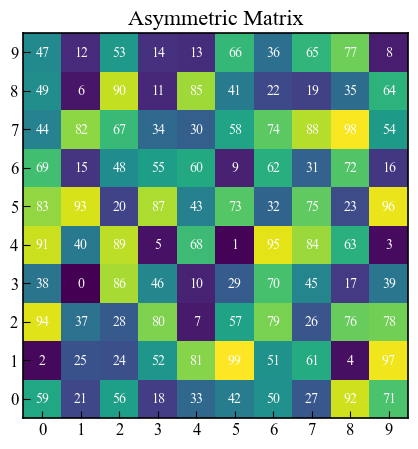

In [4]:
def create_asymmetric_matrix(n, seed=None):
    """
    Creates an n x n matrix with values from 0 to n²-1
    randomly distributed.
    """
    rng = np.random.default_rng(seed)

    values = np.arange(n * n)

    rng.shuffle(values)

    return values.reshape((n, n))


asymmetric = create_asymmetric_matrix(
    10,
    seed=42
)


plot_matrix(
    asymmetric,
    "Asymmetric Matrix"
)

## Symmetric Pattern

The symmetric matrix represents a spatially organized structure.

Values are generated according to the distance from the center of the matrix, producing radial symmetry.

This type of structure is expected to generate a more organized gradient field.

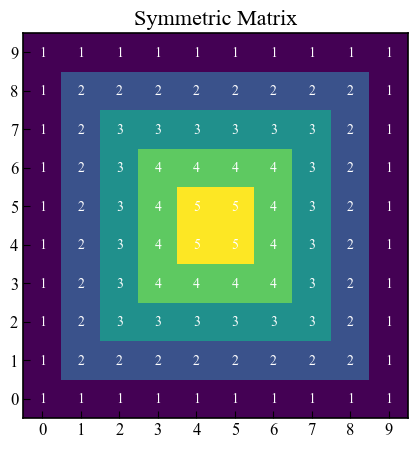

In [5]:
def create_symmetric_matrix(n):

    center = (n - 1) / 2

    matrix = np.zeros(
        (n, n),
        dtype=int
    )

    for i in range(n):
        for j in range(n):

            distance = max(
                abs(i - center),
                abs(j - center)
            )

            matrix[i, j] = int(
                center + 1 - distance
            )

    return matrix


symmetric = create_symmetric_matrix(10)


plot_matrix(
    symmetric,
    "Symmetric Matrix"
)

## Laminar Pattern

The laminar pattern represents an ordered structure with a continuous gradient.

Values increase sequentially along the matrix, producing aligned gradient vectors.

This type of pattern is useful for testing GPA response to highly organized structures.

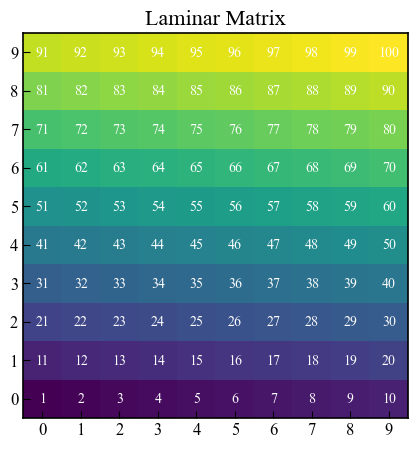

In [6]:
def create_laminar_matrix(n):
    """
    Creates an n x n matrix with increasing values row by row.
    """

    return np.arange(
        1,
        n*n + 1
    ).reshape(n, n)


laminar = create_laminar_matrix(10)


plot_matrix(
    laminar,
    "Laminar Matrix"
)

## Applying Gradient Pattern Analysis

The GPA object receives a two-dimensional scalar field.

After initialization, the spatial position used as reference for the analysis can be defined using `setPosition()`. This position represents the **center of symmetry** used by GPA when identifying radially symmetric gradient patterns.

If `setPosition()` is not called, the center of the image is used automatically.

The `evaluate()` method performs the GPA analysis and computes the selected gradient moments. It accepts several parameters that control gradient filtering and the identification of symmetric vector pairs.

### Evaluating the GPA

The main parameters of `evaluate()` are:

#### Gradient magnitude

* `magnitude_threshold`: relative threshold used to remove gradient vectors with very small magnitudes. It is expressed as a fraction of the maximum gradient magnitude. For example, `0.01` removes vectors with magnitudes below 1% of the maximum.

#### Symmetry criteria

GPA can identify approximately opposite gradient vectors using two alternative approaches.

* `opposite_vector_tolerance`: tolerance for the normalized residual of the sum of two vectors. It controls how much two vectors can deviate from being perfectly opposite. For example, `0.3` allows a residual of up to 30%.

* `magnitude_tolerance`: relative tolerance for comparing the magnitudes of two vectors. It is used only when `opposite_vector_tolerance=None`. For example, `0.05` corresponds to 5%.

* `angle_tolerance`: angular tolerance used to compare the orientations of two vectors. It is specified in degrees and is used only when `opposite_vector_tolerance=None`.

* `symmetric_position_tolerance`: relative tolerance used to determine whether two pixels are approximately opposite with respect to the analysis center. It is expressed as a percentage of the image dimensions. For example, `0.01` corresponds to 0.01% of the image width and height.

* `radial_distance_tolerance`: tolerance used to group pixels with similar radial distances from the analysis center. It is expressed in pixels.

When `opposite_vector_tolerance` is provided, it takes precedence over `magnitude_tolerance` and `angle_tolerance`.

#### Additional parameters

* `mask`: optional binary mask defining which pixels are included in the analysis. Pixels with value `0` are excluded.

* `moments`: defines which GPA moments are calculated. The available moments are `G1`, `G2`, `G3`, and `G4`. If omitted, all four moments are calculated.

In this example, the default parameters are used and all four gradient moments are calculated.

```python
results = gpaObject.evaluate()
results
```

### Visualizing the GPA Analysis

The GPA object provides different visualization methods to inspect the gradient field and the symmetry analysis.

#### Delaunay triangulation

```python
gpaObject.plot_delaunay_triangulation(
    show_center=False,
    show_image=False,
    show_scale=True,
    line_color="black"
)
```

`plot_delaunay_triangulation()` displays the asymmetric gradient vectors and their Delaunay triangulation.

Its main visualization parameters are:

* `show_center`: displays the analysis center when `True`.
* `show_image`: displays the original scalar field as the background when `True`.
* `show_scale`: displays the plot scale and axes when `True`.
* `line_color`: defines the color of the Delaunay triangulation lines.

#### Gradient field

```python
gpaObject.plot_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=True
)
```

`plot_gradient_field()` displays the original gradient field computed from the scalar field.

The main parameters are:

* `show_center`: displays the analysis center.
* `show_image`: displays the original scalar field in the background.
* `show_scale`: displays the plot scale and axes.
* `color`: defines the color of the gradient vectors.
* `fixed_length`: controls the vector length. When `True`, all vectors are displayed with the same length, emphasizing their orientation. When `False`, their lengths are proportional to their gradient magnitudes.

#### Asymmetric gradient field

```python
gpaObject.plot_asymmetric_gradient_field(
    show_center=False,
    show_image=False,
    show_scale=True,
    color="black",
    fixed_length=True
)
```

`plot_asymmetric_gradient_field()` displays the gradient field after the symmetric gradient vectors have been removed.

It uses the same visualization parameters as `plot_gradient_field()`:

* `show_center`: displays the analysis center.
* `show_image`: displays the original scalar field in the background.
* `show_scale`: displays the plot scale and axes.
* `color`: defines the color of the vectors.
* `fixed_length`: controls whether all vectors have the same displayed length or retain lengths proportional to their gradient magnitudes.

Together, these visualizations allow the original gradient field, the resulting asymmetric field, and its spatial organization through Delaunay triangulation to be inspected directly.


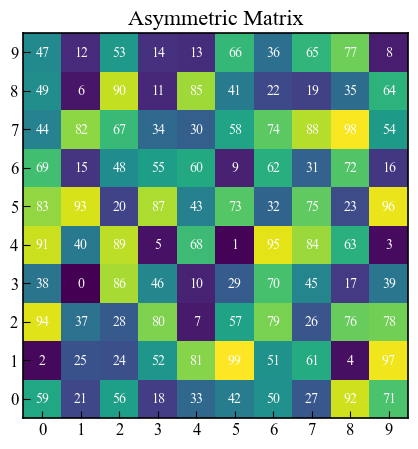

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 1.8229166666666667, 'G2': np.float32(1.8504796), 'G3': None, 'G4': None}

In [7]:
plot_matrix(
    asymmetric,
    "Asymmetric Matrix"
)

gpaObject = GPA(asymmetric)

results = gpaObject.evaluate()

results

#### GPA Visualizations

Three complementary visualizations are available:

- `plot_gradient_field()` displays the original gradient field computed from
  the scalar field.
- `plot_asymmetric_gradient_field()` displays the gradient field after
  removing approximately symmetric gradient-vector pairs.
- `plot_delaunay_triangulation()` displays the spatial organization of the
  remaining asymmetric gradient vectors through their Delaunay triangulation.

These methods can be customized through optional parameters controlling the
display of the image, analysis center, scale, vector color, vector length,
and triangulation line color.

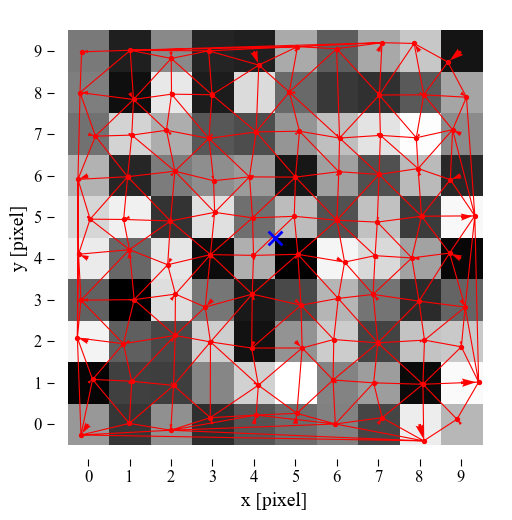

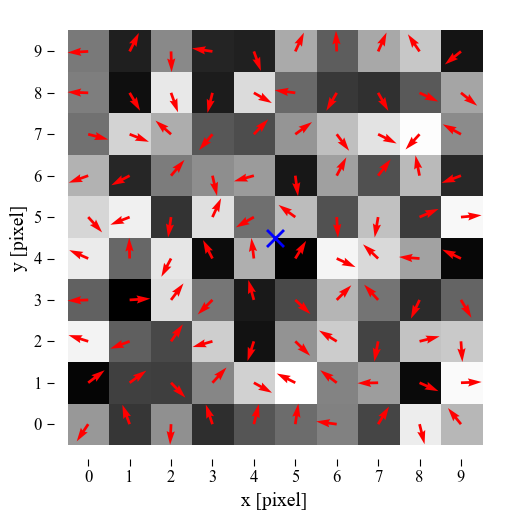

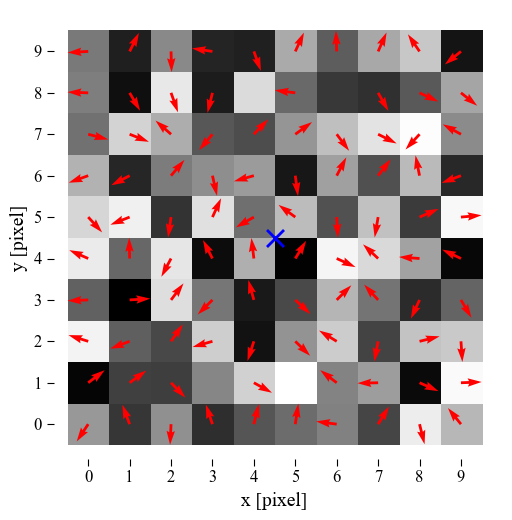

In [8]:
gpaObject.plot_delaunay_triangulation()

gpaObject.plot_gradient_field()

gpaObject.plot_asymmetric_gradient_field()

### Symmetric Pattern

A symmetric gradient pattern is used to illustrate the removal of
radially symmetric gradient-vector pairs.

In this case, the gradient vectors exhibit a high degree of symmetry
with respect to the analysis center. Therefore, most symmetric
contributions are removed during the GPA evaluation.

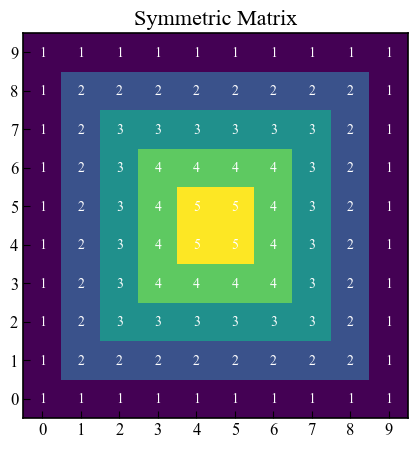

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 0.0, 'G2': 0.0, 'G3': None, 'G4': None}

In [9]:
plot_matrix(
    symmetric,
    "Symmetric Matrix"
)

gpaObject_symmetric = GPA(symmetric)

results_symmetric = gpaObject_symmetric.evaluate()

results_symmetric

No asymmetric gradient vectors remaining.


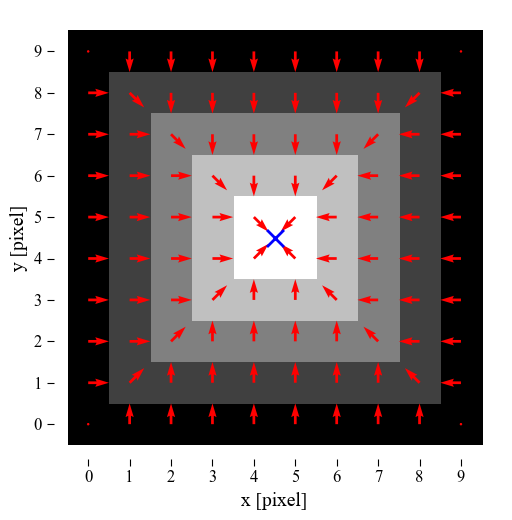

No asymmetric gradient vectors remaining.


In [10]:
gpaObject_symmetric.plot_delaunay_triangulation()

gpaObject_symmetric.plot_gradient_field()

gpaObject_symmetric.plot_asymmetric_gradient_field()

### Laminar Pattern

A laminar gradient pattern is used to illustrate a highly organized
gradient field with approximately parallel structures.

This example demonstrates how GPA characterizes the asymmetry of an
ordered gradient pattern after the removal of approximately symmetric
gradient-vector pairs.

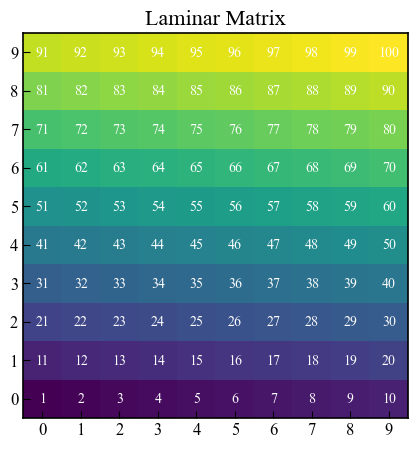

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 1.61, 'G2': np.float32(0.9999993), 'G3': None, 'G4': None}

In [11]:
plot_matrix(
    laminar,
    "Laminar Matrix"
)

gpaObject_laminar = GPA(laminar)

results_laminar = gpaObject_laminar.evaluate()

results_laminar

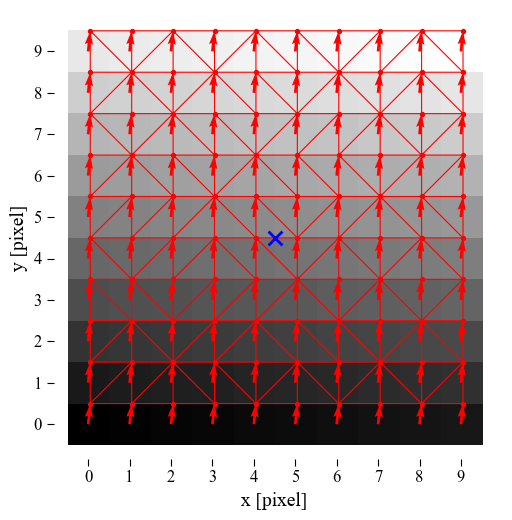

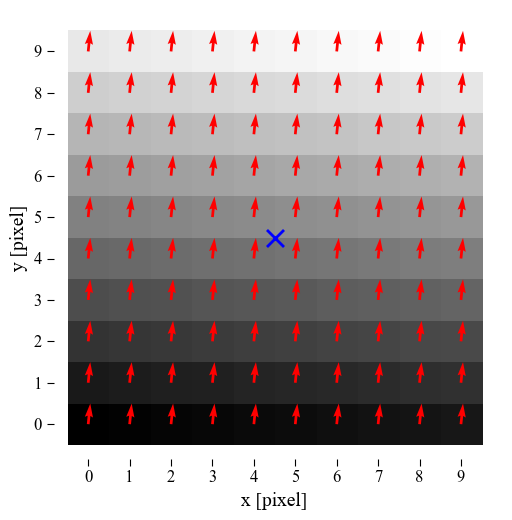

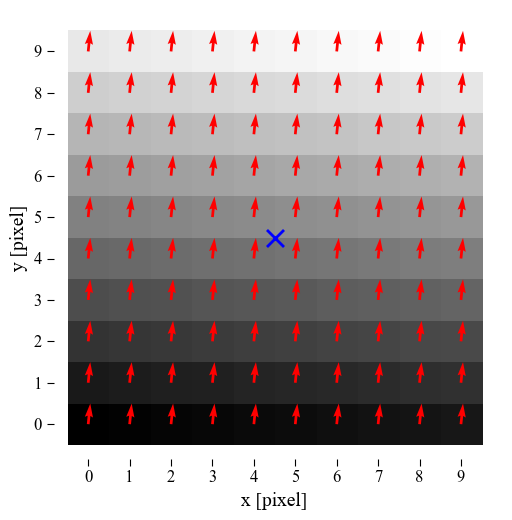

In [12]:
gpaObject_laminar.plot_delaunay_triangulation()

gpaObject_laminar.plot_gradient_field()

gpaObject_laminar.plot_asymmetric_gradient_field()

### Using a Segmentation Mask

GPA can be applied to a specific region of the input matrix using a binary
segmentation mask.

Pixels with mask value `1` are included in the analysis, while pixels with
mask value `0` are excluded. This is useful when the region of interest is
only a subset of the complete scalar field.

The following example creates a matrix containing a symmetric pattern and
defines a smaller region of interest using a binary mask.


In [13]:
matrix = np.random.randint(
    0,
    10,
    (15, 15)
).astype(np.float32)

symmetric = create_symmetric_matrix(5).astype(np.float32)

matrix[5:10, 5:10] = symmetric

mask = np.zeros_like(matrix, dtype=np.uint8)

mask[6:9, 6:9] = 1

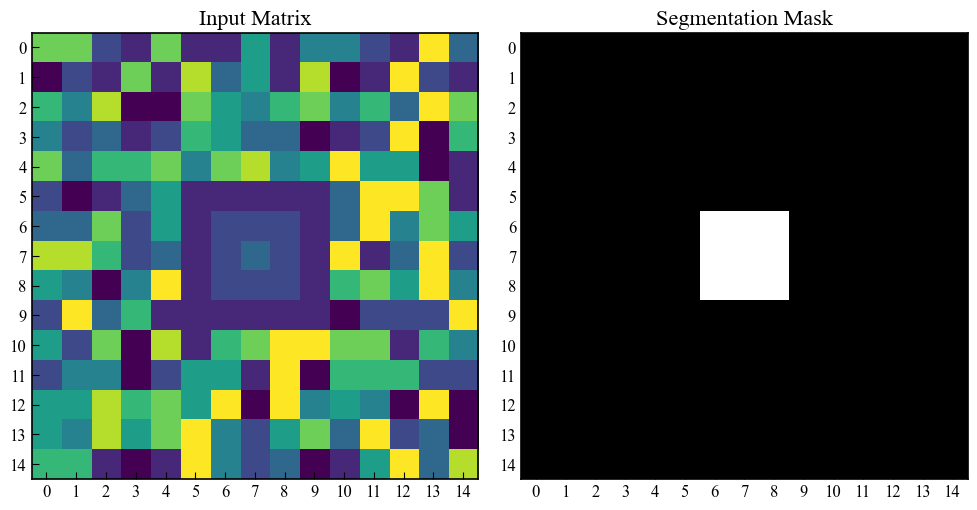

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(matrix, cmap="viridis")
ax[0].set_title("Input Matrix")
ax[0].set_xticks(range(matrix.shape[1]))
ax[0].set_yticks(range(matrix.shape[0]))

ax[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Segmentation Mask")
ax[1].set_xticks(range(mask.shape[1]))
ax[1].set_yticks(range(mask.shape[0]))

plt.tight_layout()
plt.show()

In [15]:
gpa_without_mask = GPA(matrix)

result_without_mask = gpa_without_mask.evaluate()

result_without_mask

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 1.9120879120879122, 'G2': np.float32(1.5886209), 'G3': None, 'G4': None}

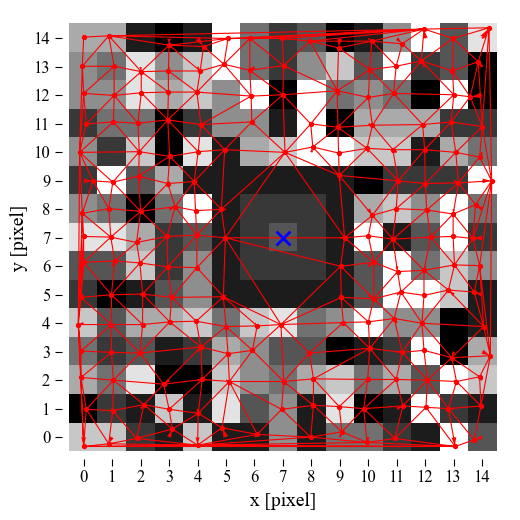

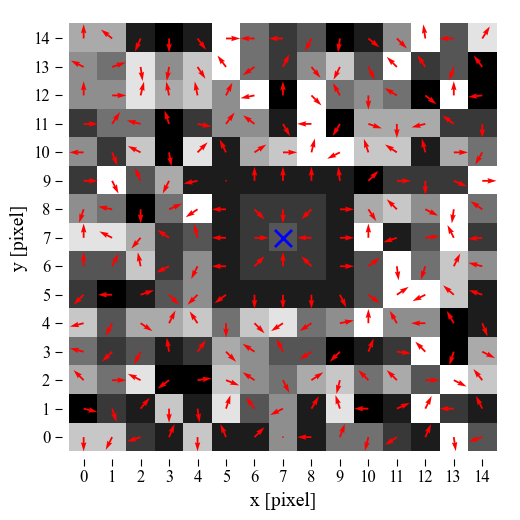

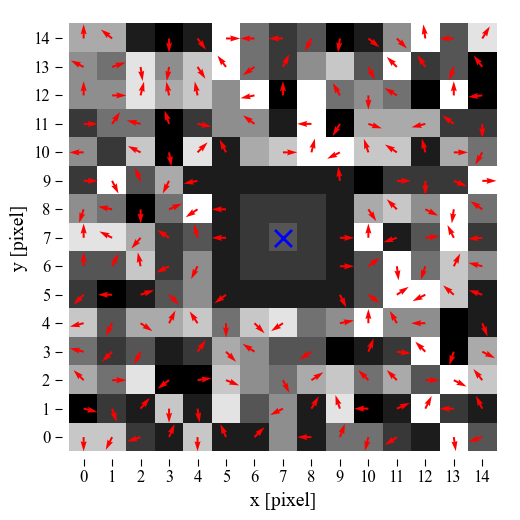

In [16]:
gpa_without_mask.plot_delaunay_triangulation()

gpa_without_mask.plot_gradient_field()

gpa_without_mask.plot_asymmetric_gradient_field()

In [17]:
gpa_with_mask = GPA(matrix)

result_with_mask = gpa_with_mask.evaluate(
    mask=mask
)

result_with_mask

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'G1': 1.925233644859813, 'G2': 0.0, 'G3': None, 'G4': None}

No asymmetric gradient vectors remaining.


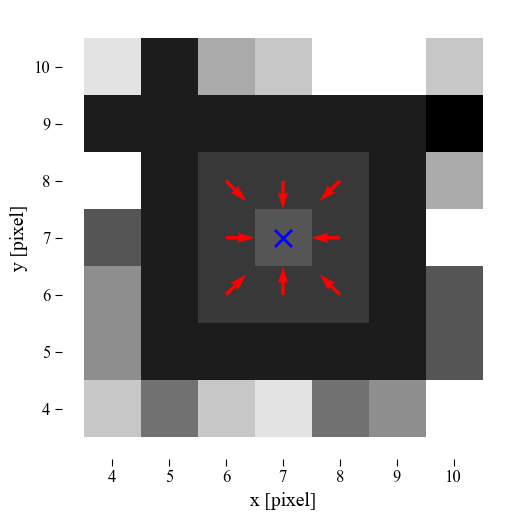

No asymmetric gradient vectors remaining.


In [18]:
gpa_with_mask.plot_delaunay_triangulation()

gpa_with_mask.plot_gradient_field()

gpa_with_mask.plot_asymmetric_gradient_field()

#### Effect of the Segmentation Mask

Without a mask, GPA analyzes the complete input matrix. When a segmentation
mask is provided, only the selected region contributes to the analysis.

The comparison between the two cases illustrates how the mask can be used to
isolate a specific structure or region of interest within a larger scalar
field.

### Comparing GPA Moments

The GPA moments provide quantitative descriptors of the spatial organization
of a gradient pattern.

After applying the same GPA configuration to the three reference patterns,
the resulting moments can be compared to investigate how their different
spatial structures are reflected in the GPA descriptors.

The following function applies GPA to a given matrix and returns its gradient
moments.

In [19]:
def run_gpa(matrix):
    gpa = GPA(matrix)
    return gpa.evaluate()

results = {
    "Asymmetric": run_gpa(asymmetric),
    "Symmetric": run_gpa(symmetric),
    "Laminar": run_gpa(laminar),
}

results

/Users/carloseduardofalandes/Documents/master/gpa-temp/src/gpa/gpa.py:284: UserWarning: angle_tolerance is greater than pi radians. This may cause a large number of gradient vectors to be considered approximately opposite.
  warnings.warn(


{'Asymmetric': {'G1': 1.8229166666666667,
  'G2': np.float32(1.8504796),
  'G3': None,
  'G4': None},
 'Symmetric': {'G1': 0.0, 'G2': 0.0, 'G3': None, 'G4': None},
 'Laminar': {'G1': 1.61, 'G2': np.float32(0.9999993), 'G3': None, 'G4': None}}

In [20]:
import pandas as pd

moments_df = pd.DataFrame(results).T

moments_df

,G1,G2,G3,G4
Asymmetric,1.822917,1.850480,NaN,NaN
Symmetric,0.000000,0.000000,NaN,NaN
Laminar,1.610000,0.999999,NaN,NaN


## Discussion of GPA Moments

The first two GPA moments, G1 and G2, show a clear distinction between the
three reference patterns.

For a perfectly symmetric pattern, both moments tend toward **0**, as the
gradient vectors are predominantly removed through the symmetry analysis.
This behavior is observed for the symmetric pattern, for which
`G1 = 0` and `G2 = 0`.

For a laminar pattern, the moments tend toward **1**, reflecting a more
organized and approximately parallel gradient structure. In the present
example, `G1 = 1.24` and `G2 = 1.00`.

For an asymmetric pattern, the moments tend toward **2**, indicating a
stronger contribution from asymmetric gradient structures. The asymmetric
pattern produces `G1 = 1.37` and `G2 = 1.35`, placing it between the laminar
and the idealized asymmetric limits.

Thus, G1 and G2 provide quantitative descriptors that distinguish the
increasing degree of asymmetry among the reference patterns, with values
approximately associated with:

* **0** → symmetric patterns
* **1** → laminar patterns
* **2** → asymmetric patterns

These values should be interpreted as characteristic limits of the
idealized patterns rather than strict boundaries for arbitrary gradient
fields.

## GPA Moments as a Function of Matrix Scale

The previous comparison showed that the GPA moments can distinguish between
symmetric, laminar, and asymmetric patterns.

To investigate the dependence of these descriptors on spatial scale, the
analysis is repeated for asymmetric and laminar matrices with increasing
dimensions.

The matrices are generated using `create_asymmetric_matrix()` and
`create_laminar_matrix()` for the following sizes:

`3 × 3`, `5 × 5`, `10 × 10`, `20 × 20`, `30 × 30`, `40 × 40`, `64 × 64`,
`80 × 80`, and `100 × 100`.

Because the matrix-generation functions depend on a random seed, a single
realization at each matrix size may not be representative of the generated
pattern. Therefore, 50 independent realizations are generated for each
matrix size using different random seeds.

GPA is applied to each realization, and the mean and standard deviation of
each gradient moment are calculated. The mean describes the average behavior
of the GPA descriptor at a given spatial scale, while the standard deviation
quantifies the variability between different realizations of the same
pattern.

The resulting values are then compared as a function of matrix size to
evaluate the scale dependence and statistical variability of the GPA
descriptors.


In [21]:
sizes = [
    3,
    5,
    10,
    20,
    30,
    40,
    64,
    80,
    100
]


def calculate_moments(matrix):

    gpa = GPA(
        matrix.astype(np.float32)
    )

    return gpa.evaluate(
        moments=["G1", "G2"],
        magnitude_threshold=0,
        magnitude_tolerance=0,
        angle_tolerance=0,
        radial_distance_tolerance=0,
        symmetric_position_tolerance=0
    )


n_samples = 10

moments = ["G1", "G2"]

results_scale = []


for size in sizes:

    # Asymmetric: multiple random realizations

    asymmetric_values = {
        moment: []
        for moment in moments
    }

    for seed in range(n_samples):

        asymmetric_matrix = create_asymmetric_matrix(
            size,
            seed=seed
        )

        asymmetric_result = calculate_moments(
            asymmetric_matrix
        )

        for moment in moments:

            asymmetric_values[moment].append(
                asymmetric_result[moment]
            )


    # Laminar: single deterministic realization

    laminar_matrix = create_laminar_matrix(size)

    laminar_result = calculate_moments(
        laminar_matrix
    )


    # Store results

    row = {
        "Size": size
    }

    for moment in moments:

        row[f"Asymmetric_{moment}_mean"] = np.nanmean(
            asymmetric_values[moment]
        )

        row[f"Asymmetric_{moment}_std"] = np.nanstd(
            asymmetric_values[moment]
        )

        row[f"Laminar_{moment}"] = laminar_result[moment]

    results_scale.append(row)


results_scale_df = pd.DataFrame(
    results_scale
)

results_scale_df

,Size,Asymmetric_G1_mean,Asymmetric_G1_std,Laminar_G1,Asymmetric_G2_mean,Asymmetric_G2_std,Laminar_G2
0,3,0.977778,0.163299,0.777778,1.638790,0.126464,1.000000
1,5,1.560000,0.056569,1.240000,1.781487,0.133585,1.000000
2,10,1.843000,0.011000,1.610000,1.930814,0.041104,0.999999
3,20,1.953000,0.008860,1.802500,1.974992,0.019413,0.999997
4,30,1.979000,0.002959,1.867778,1.983353,0.007389,1.000011
5,40,1.985563,0.001778,1.900625,1.986447,0.005269,0.999986
6,64,1.994482,0.000537,1.937744,1.995265,0.002608,0.999939
7,80,1.996078,0.000491,1.950156,1.995296,0.001345,0.999945
8,100,1.997560,0.000310,1.960100,1.996311,0.001689,0.999958


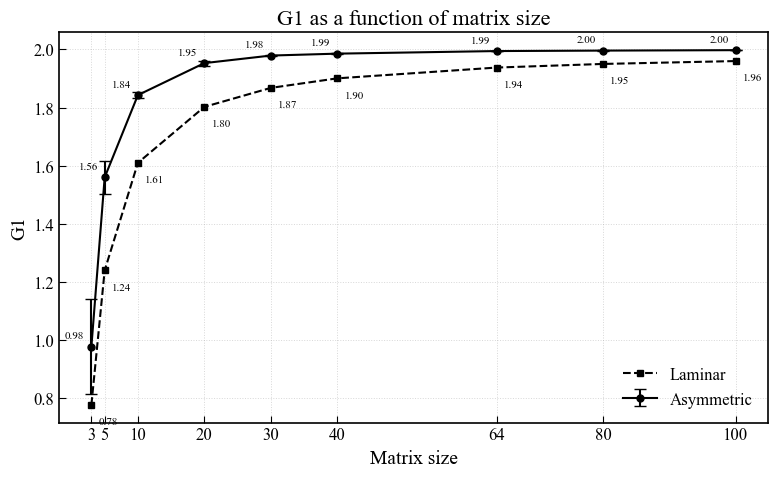

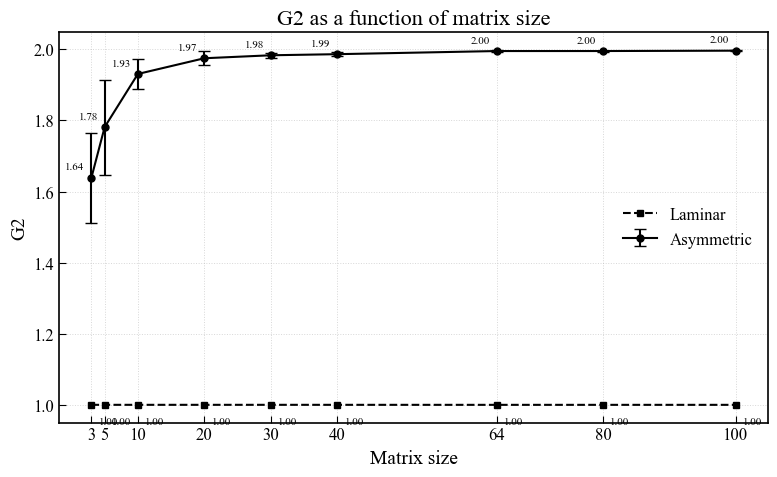

In [22]:
for moment in moments:

    fig, ax = plt.subplots(figsize=(8, 5))

    x = results_scale_df["Size"]

    asymmetric_mean = results_scale_df[
        f"Asymmetric_{moment}_mean"
    ]

    asymmetric_std = results_scale_df[
        f"Asymmetric_{moment}_std"
    ]

    laminar = results_scale_df[
        f"Laminar_{moment}"
    ]

    # Asymmetric: mean ± standard deviation
    ax.errorbar(
        x,
        asymmetric_mean,
        yerr=asymmetric_std,
        color="black",
        linestyle="-",
        marker="o",
        markersize=5,
        capsize=4,
        linewidth=1.5,
        label="Asymmetric"
    )

    # Laminar: deterministic
    ax.plot(
        x,
        laminar,
        color="black",
        linestyle="--",
        marker="s",
        markersize=5,
        linewidth=1.5,
        label="Laminar"
    )

    # Values
    for xi, yi in zip(x, asymmetric_mean):

        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(-12, 6),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    for xi, yi in zip(x, laminar):

        ax.annotate(
            f"{yi:.2f}",
            (xi, yi),
            xytext=(12, -14),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

    ax.set_xlabel("Matrix size")
    ax.set_ylabel(moment)

    ax.set_xticks(x)

    ax.grid(
        True,
        linestyle=":",
        linewidth=0.7,
        alpha=0.5
    )

    ax.legend(
        frameon=False
    )

    plt.title(
        f"{moment} as a function of matrix size"
    )

    plt.tight_layout()
    plt.show()